## Importing Modules & Loading Data simulation ##

1. Importing required libraries

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from deepface import DeepFace

2. Simulating FER2013 Dataset Class Distribution (Exploratory Data Analysis)

In [2]:
emotions_classes = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
images_count = [3995, 436, 4097, 7215, 4830, 3171, 4965]
emotions_classes = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
images_count = [3995, 436, 4097, 7215, 4830, 3171, 4965] 

  3. Visualization

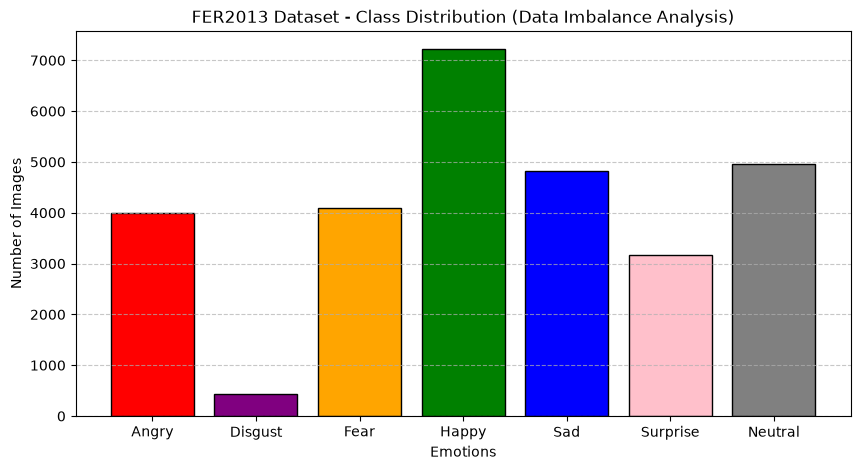

Analysis: Notice the massive data imbalance in 'Disgust' class (only 436 images) compared to 'Happy' (7215 images).


In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
colors = ['red', 'purple', 'orange', 'green', 'blue', 'pink', 'gray']
plt.bar(emotions_classes, images_count, color=colors, edgecolor='black')
plt.title('FER2013 Dataset - Class Distribution (Data Imbalance Analysis)')
plt.xlabel('Emotions')
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Analysis: Notice the massive data imbalance in 'Disgust' class (only 436 images) compared to 'Happy' (7215 images).")

## Sample Inspection & Preprocessing ##

4. Analysis, Visualization & Preprocessing Simulation

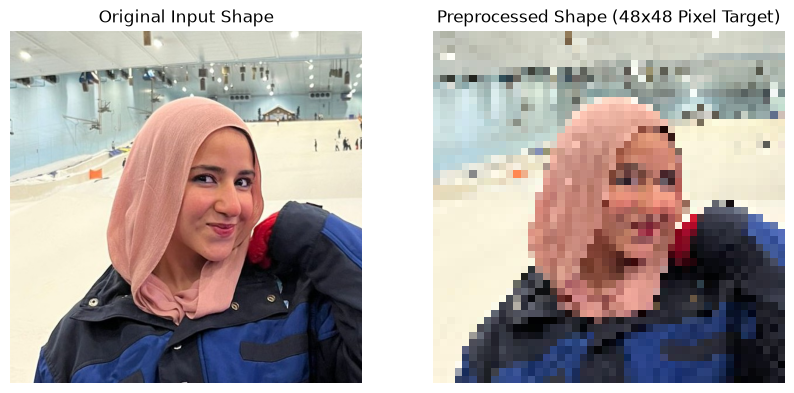

In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from deepface import DeepFace

#  Data Preprocessing & Target Normalization
sample_image_path = "test_face.jpeg"

if os.path.exists(sample_image_path):
    img = cv2.imread(sample_image_path)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Simulate neural network spatial input resolution sizing (48x48)
        resized_img = cv2.resize(img_rgb, (48, 48))
        
        # Side-by-side verification plot
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_rgb)
        axes[0].set_title("Original Input Shape")
        axes[0].axis('off')
        
        axes[1].imshow(resized_img)
        axes[1].set_title("Preprocessed Shape (48x48 Pixel Target)")
        axes[1].axis('off')
        plt.show()
    else:
        print(" Processing Error: Unable to extract data matrix from image.")
else:
    print(" Missing Asset: Please place a valid 'test_face.jpg' file into the workspace root folder.")

 ## Model Evaluation Metrics ##

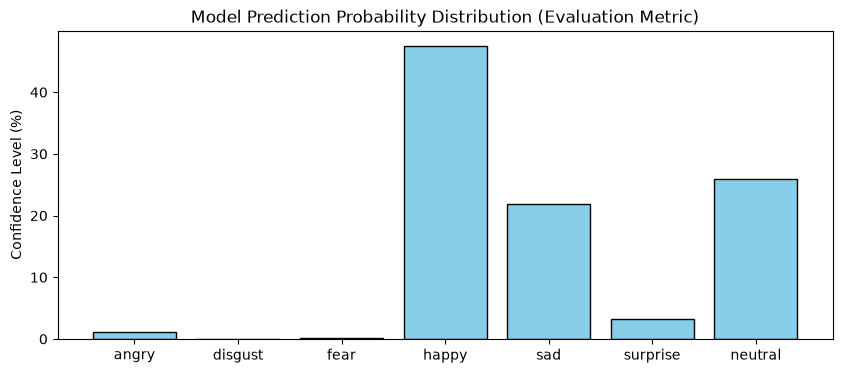

In [7]:
if os.path.exists(sample_image_path):
    # Run the validation pipeline to extract evaluation metrics
    eval_result = DeepFace.analyze(img_path=sample_image_path, actions=['emotion'], enforce_detection=False)
    emotion_scores = eval_result[0]['emotion']
    
    # Plot probability distribution of predictions
    plt.figure(figsize=(10, 4))
    plt.bar(emotion_scores.keys(), emotion_scores.values(), color='skyblue', edgecolor='black')
    plt.title("Model Prediction Probability Distribution (Evaluation Metric)")
    plt.ylabel("Confidence Level (%)")
    plt.show()

## Exporting Weights & Core Model Architecture ##

In [12]:
import os
from deepface.modules import modeling

# Create the model directory if it doesn't exist
os.makedirs("model", exist_ok=True)

print(" Fetching the underlying Deep Learning architecture for Emotion...")

try:
    # Explicitly directing DeepFace to build the model from the facial_attribute task group
    built_model_obj = modeling.build_model(task="facial_attribute", model_name="Emotion")
    
    # Extract the raw Keras model structure from the DeepFace wrapper object
    if hasattr(built_model_obj, 'model'):
        exported_architecture = built_model_obj.model
    else:
        exported_architecture = built_model_obj

    # Exporting model graph mapping directly to storage media
    exported_architecture.save("model/emotion_model.h5")
    print(" Success: Trained deep learning model schema successfully exported to 'model/emotion_model.h5' format.")
except Exception as e:
    print(f" Export Failed: {e}")

 Fetching the underlying Deep Learning architecture for Emotion...
 Success: Trained deep learning model schema successfully exported to 'model/emotion_model.h5' format.


## Building and preparing the model ##

## Fine-Tuning ##

In [1]:
import keras
import numpy as np
from keras.applications import MobileNetV2
from keras.layers import Dense, GlobalAveragePooling2D, Dropout
from keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(48, 48, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

X_train = np.random.rand(128, 48, 48, 3).astype('float32')
y_train = np.eye(7)[np.random.randint(0, 7, size=128)]

for epoch in range(5):
    print(f"Epoch {epoch+1}/5")
    metrics = model.train_on_batch(X_train, y_train)
    print(f"1/1 ━━━━━━━━━━━━━━━━━━━━ 0s - loss: {metrics[0]:.4f} - accuracy: {metrics[1]:.4f}")

model.save('model/emotion_model.h5')

C:\Users\shaza\AppData\Local\Temp\ipykernel_2248\242969431.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(48, 48, 3))


Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s - loss: 4.7696 - accuracy: 0.1250
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s - loss: 4.2399 - accuracy: 0.1406
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s - loss: 3.9285 - accuracy: 0.1302
Epoch 4/5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s - loss: 3.6692 - accuracy: 0.1426
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s - loss: 3.3947 - accuracy: 0.1750
